# Classifier Analysis

## 1) Setup

In [1]:
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing 'src' directory.")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.preparation import prepare_data
from src.train.config_setup import load_and_prepare_model
from src.utils.mask_utils import get_non_pad_mask
from src.utils.metrics import classification_metrics
from src.utils.utils import _to_np_datetime64_seconds, set_seed
import src.data.event_loader as loader
import src.utils.viz_analysis as analysis
import src.utils.viz_interpretability as interp

set_seed(0)
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
FIG_DIR = PROJECT_ROOT / 'notebooks' / 'figs'
FIG_BATCH_DIR = FIG_DIR / 'clf'
FIG_DIR.mkdir(parents=True, exist_ok=True)
FIG_BATCH_DIR.mkdir(parents=True, exist_ok=True)

data_start = [1970, 1, 1, 0, 0, 0]
t0_np = _to_np_datetime64_seconds(datetime(*data_start))

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DEVICE: {DEVICE}')

PROJECT_ROOT: /root/autodl-tmp/em_eqf
DEVICE: cuda:0


## 2) Load Checkpoint and Data

In [14]:
CHECKPOINT_DIR = PROJECT_ROOT / 'checkpoints' / 'clf_mixer_attnpl_t_20260205-213430'
CHECKPOINT_PATH = CHECKPOINT_DIR / 'best_model_1.pth'
USE_TORCH_COMPILE = False
BATCH_SIZE = 32


model, args = load_and_prepare_model(
    checkpoint_path=CHECKPOINT_PATH,
    device=DEVICE,
    compile=USE_TORCH_COMPILE,
)
args.use_sampler = False
args.batch_size = BATCH_SIZE

base_dir = PROJECT_ROOT / 'data' / args.dataset
df, train_loader, val_loader, test_loader, catalog_ds = prepare_data(base_dir=str(base_dir), args=args)
data_loader = loader.get_dataloader(
    catalog_ds,
    batch_size=args.batch_size,
    shuffle=False,
    task_type=args.task_type,
)

print(f'Loaded checkpoint: {CHECKPOINT_PATH}')
print(f'Dataset: {args.dataset}')

Loaded checkpoint: /root/autodl-tmp/em_eqf/checkpoints/clf_mixer_attnpl_t_20260205-213430/best_model_1.pth
Dataset: ChuanDian


## 3) Representation Probe

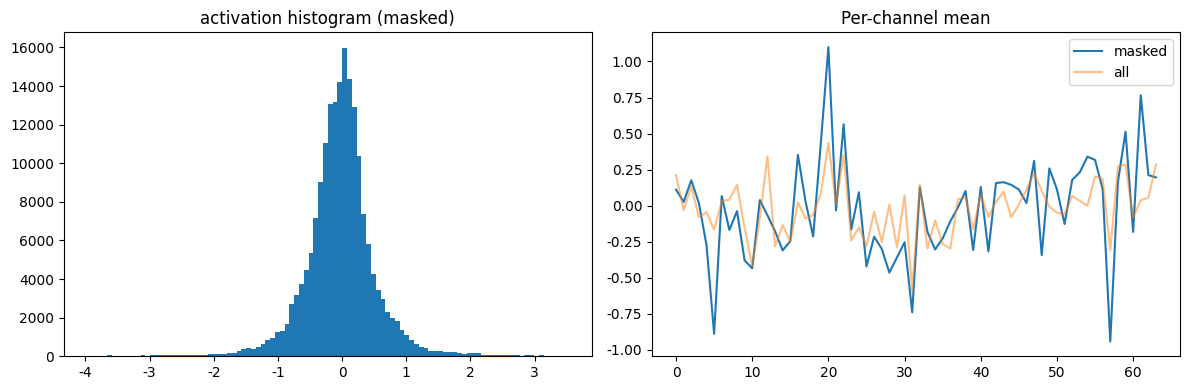

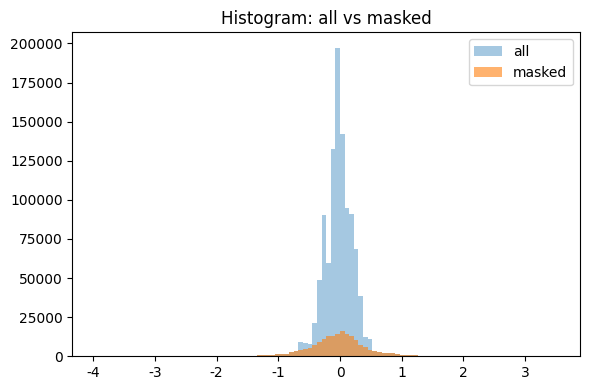

In [15]:
x_batch, y_batch = next(iter(data_loader))
x_batch = x_batch.to(DEVICE)
y_batch = y_batch.to(DEVICE)

valid_mask = get_non_pad_mask(x_batch[:, :, 0]).squeeze(-1).cpu().bool()
_activations = interp.capture_layer_activations(
    model,
    x_batch,
    module=model.base_model.encoder.layers[0],
    valid_mask=valid_mask,
    visualize=True,
)

## 4) Model Metrics and t-SNE by Split

=== TRAIN: classification_metrics ===
{'precision': 0.7293972939729397, 'recall': 0.839943342776204, 'f1': 0.7807768268597761, 'auc': 0.8135550467616128, 'pr_auc': 0.9001415320217482, 'fpr': 0.502283105022831, 'tpr': 0.839943342776204, 'R': 0.33766023775337295, 'conf': 1.0, 'threshold': 0.35502922534942627}


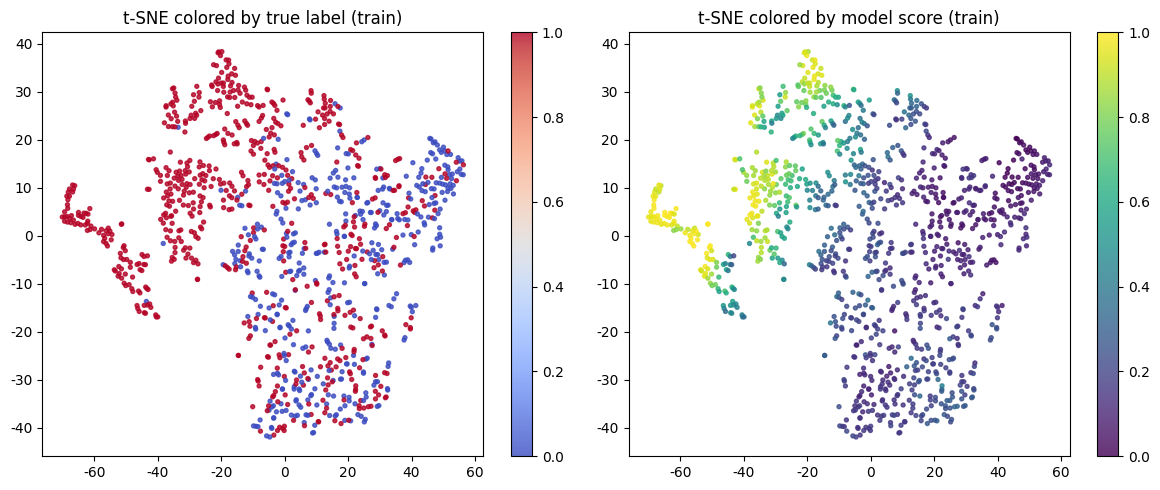

=== VAL: classification_metrics ===
{'precision': 0.6377952755905512, 'recall': 0.9759036144578314, 'f1': 0.7714285714285715, 'auc': 0.7600401606425703, 'pr_auc': 0.8371695266694815, 'fpr': 0.7666666666666667, 'tpr': 0.9759036144578314, 'R': 0.20923694779116464, 'conf': 0.0019910004391618425, 'threshold': 0.2959364354610443}


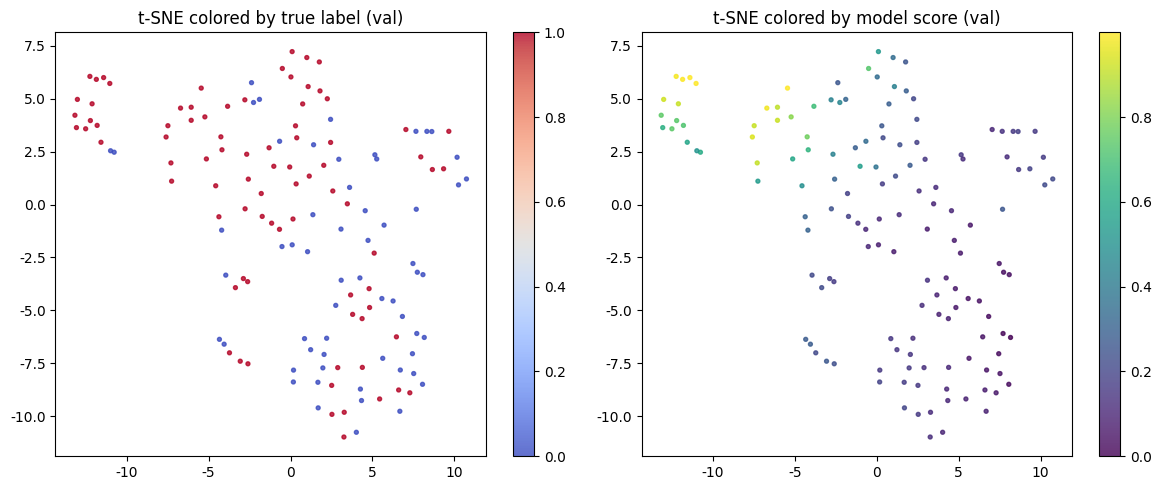

=== TEST: classification_metrics ===
{'precision': 0.9090909090909091, 'recall': 0.6382978723404256, 'f1': 0.75, 'auc': 0.8993794326241135, 'pr_auc': 0.8516222215159499, 'fpr': 0.03125, 'tpr': 0.6382978723404256, 'R': 0.6070478723404256, 'conf': 1.0, 'threshold': 0.4732005000114441}


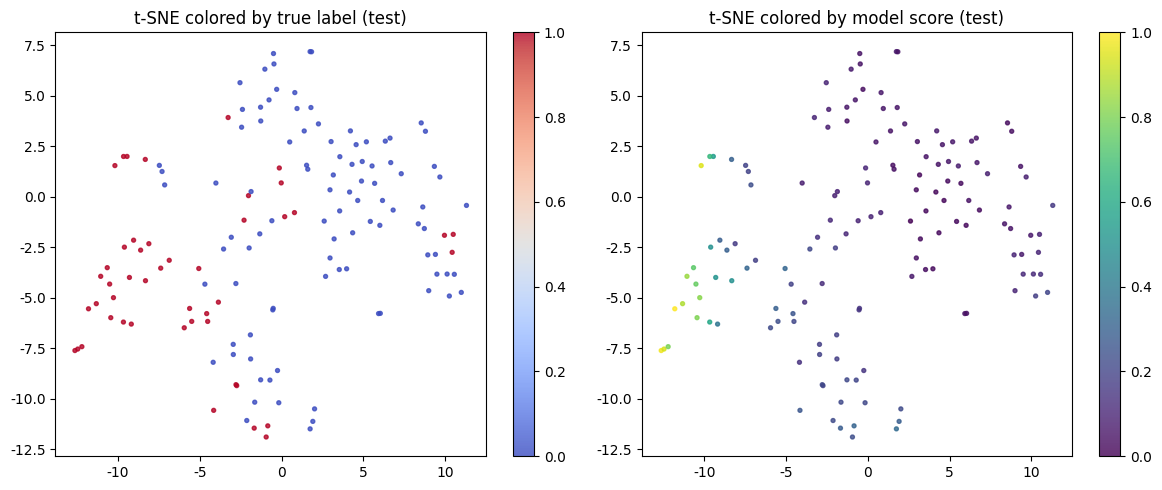

In [16]:
split_outputs = {
    'train': analysis.predict_all(model, train_loader, DEVICE, return_X=True),
    'val': analysis.predict_all(model, val_loader, DEVICE, return_X=True),
    'test': analysis.predict_all(model, test_loader, DEVICE, return_X=True),
}


def run_metrics_and_tsne(split_outputs: dict, splits=('val',), do_tsne: bool = True):
    for split in splits:
        if split not in split_outputs:
            print(f'[Skip] Unknown split: {split}')
            continue

        y_pred, y_true, x_feat = split_outputs[split]

        print(f'=== {split.upper()}: classification_metrics ===')
        try:
            print(classification_metrics(y_true, y_pred))
        except Exception as exc:
            print(f'[Warn] classification_metrics({split}) failed: {exc}')

        if do_tsne:
            try:
                analysis.tsne_scatter(
                    x_feat.astype(float),
                    y_all=y_true,
                    y_pred_all=y_pred,
                    title_left=f't-SNE colored by true label ({split})',
                    title_right=f't-SNE colored by model score ({split})',
                )
            except Exception as exc:
                print(f'[Warn] t-SNE({split}) failed: {exc}')


selected_splits = ['train', 'val', 'test']
run_metrics_and_tsne(split_outputs, splits=selected_splits, do_tsne=True)

## 5) Random Forest Baseline on Learned Features

Accuracy: 0.7622377622377622
              precision    recall  f1-score   support

         0.0     0.8444    0.7917    0.8172        96
         1.0     0.6226    0.7021    0.6600        47

    accuracy                         0.7622       143
   macro avg     0.7335    0.7469    0.7386       143
weighted avg     0.7715    0.7622    0.7655       143

ROC AUC: 0.8287898936170214


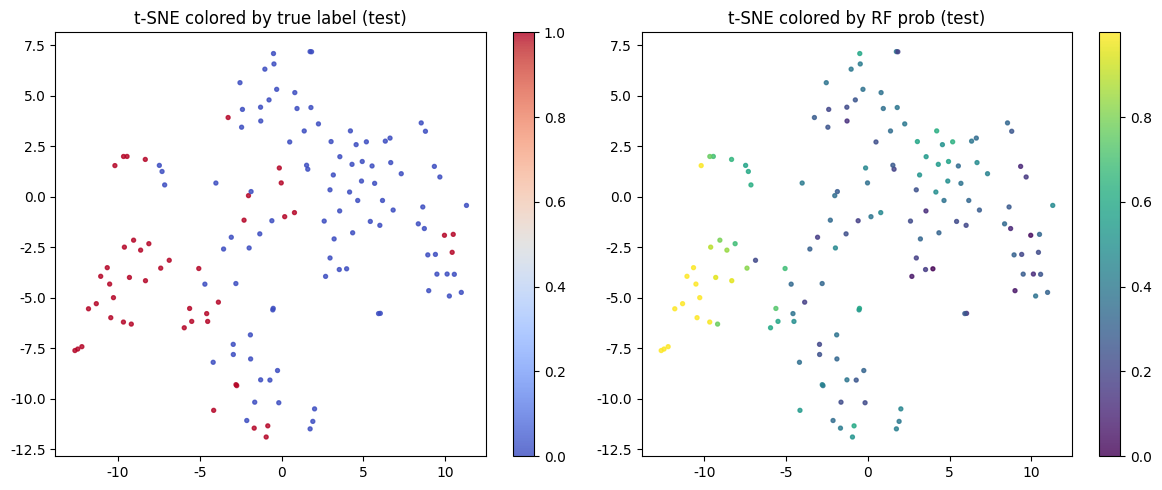

(array([[-1.10094321, -1.01868532,  0.86080316, ...,  0.24333958,
         -0.95675747, -0.51716613],
        [-0.51438018, -0.86946889,  0.64583216, ...,  0.29446326,
         -0.28173255, -0.31113068],
        [ 0.66199794, -0.58927136, -0.76747092, ...,  0.13163611,
          0.55034071, -0.00931084],
        ...,
        [ 0.27058157, -0.18302451,  0.14909765, ...,  0.92348637,
         -0.54106424, -1.01976955],
        [ 0.91524469,  0.45292013, -1.2162941 , ...,  0.27021833,
         -0.36535117, -0.92844592],
        [-1.05599906, -1.03917757,  1.29604741, ...,  1.08233248,
         -1.28140207, -1.33120889]]),
 array([[  1.7455065 ,   7.19126   ],
        [  1.8354605 ,   7.183029  ],
        [  1.603757  ,   1.3705798 ],
        [  1.5313169 ,   1.5663295 ],
        [  0.4990974 ,   2.7190573 ],
        [ -1.0198916 ,   6.3221283 ],
        [ -0.46339124,   6.5804863 ],
        [ -0.49220112,   7.0954638 ],
        [ -0.29742283,   5.323879  ],
        [  2.608509  ,  -1.1964

In [17]:
y_pred_train, y_train, X_train = split_outputs['train']
y_pred_val, y_val, X_val = split_outputs['val']
y_pred_test, y_test, X_test = split_outputs['test']

rf = RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, digits=4))
print('ROC AUC:', roc_auc_score(y_test, y_proba_rf))

analysis.tsne_scatter(
    X_test,
    y_all=y_test,
    y_pred_all=y_proba_rf,
    title_left='t-SNE colored by true label (test)',
    title_right='t-SNE colored by RF prob (test)',
)

## 6) Interpretability (Integrated Gradients)

In [18]:
import importlib
importlib.reload(interp)

<module 'src.utils.interpretability' from '/root/autodl-tmp/em_eqf/src/utils/interpretability.py'>

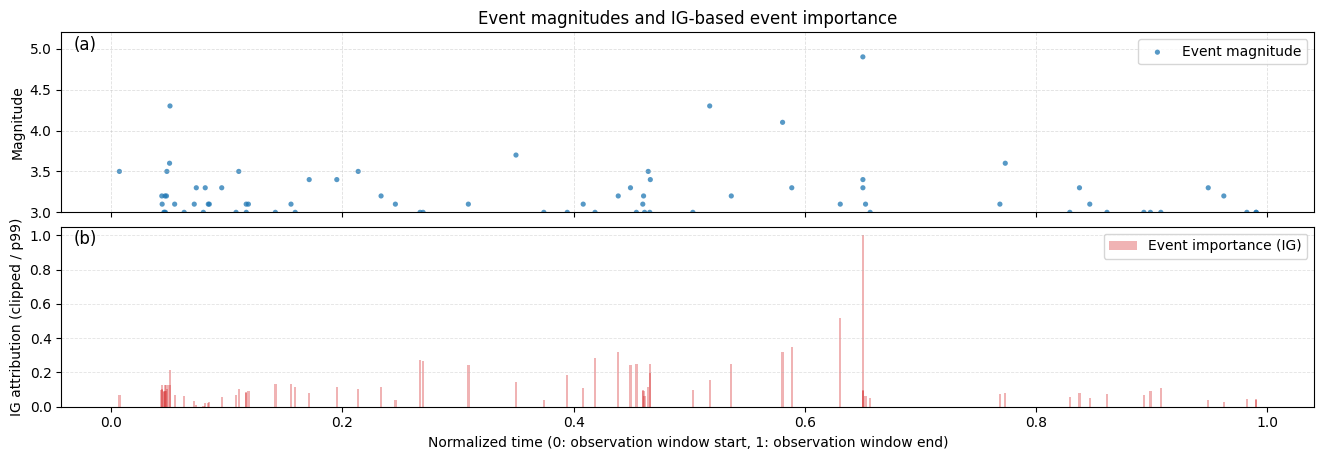

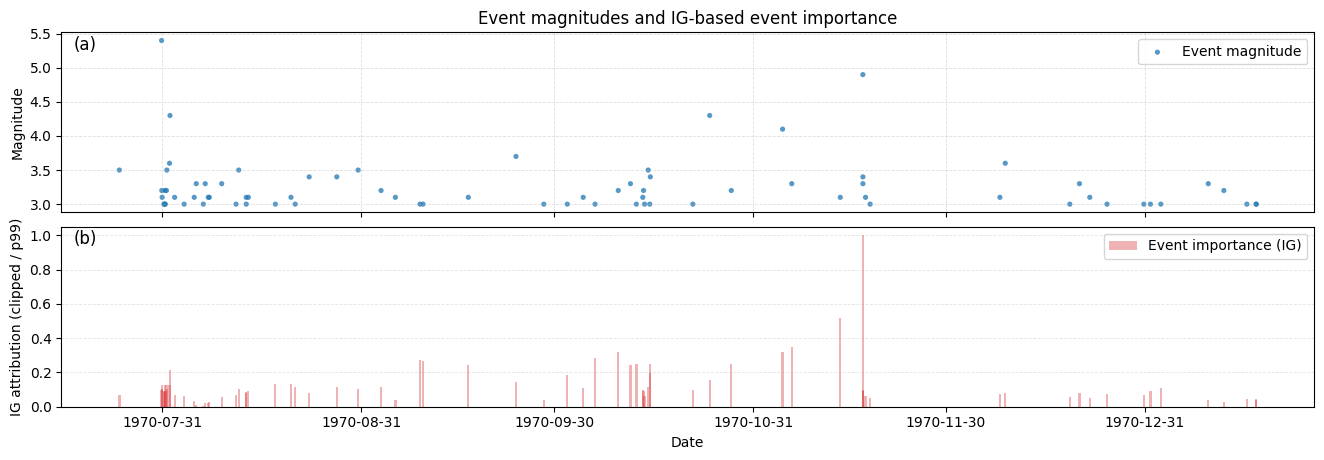

(<Figure size 1400x480 with 2 Axes>,
 <Axes: title={'center': 'Event magnitudes and IG-based event importance'}, ylabel='Magnitude'>,
 <Axes: xlabel='Date', ylabel='IG attribution (clipped / p99)'>)

In [19]:
IG_STEPS = 300
SAMPLE_IDX = 14

x_ig = next(iter(data_loader))[0].to(DEVICE)
scores, labels = interp.compute_token_importance(
    model,
    x_ig,
    method='ig',
    n_steps=IG_STEPS,
    signed=False,
)

mask_np = get_non_pad_mask(x_ig[:, :, 0]).squeeze(-1).cpu().numpy().astype(bool)

interp.plot_event_magnitude_and_importance_clean(
    x_ig,
    scores,
    batch_idx=SAMPLE_IDX,
    time_channel=1,
    mag_channel=2,
    importance_norm='p99',
    savepath=str(FIG_DIR / 'clf_interp_nl.pdf'),
    mag_color='tab:blue',
    imp_color='tab:red',
    mask=mask_np,
    height_ratios=(2, 2),
    panel_labels=('(a)', '(b)'),
)

interp.plot_event_magnitude_and_importance_clean(
    x_ig,
    scores,
    batch_idx=SAMPLE_IDX,
    time_channel=0,
    x_axis='time',
    start_time=t0_np,
    time_scale=1.0,
    time_unit='D',
    mag_channel=2,
    importance_norm='p99',
    savepath=str(FIG_DIR / 'clf_interp.pdf'),
    mag_color='tab:blue',
    imp_color='tab:red',
    mask=mask_np,
    height_ratios=(2, 2),
    xlabel='Date',
    clip_mag =None,
    panel_labels=('(a)', '(b)'),
)

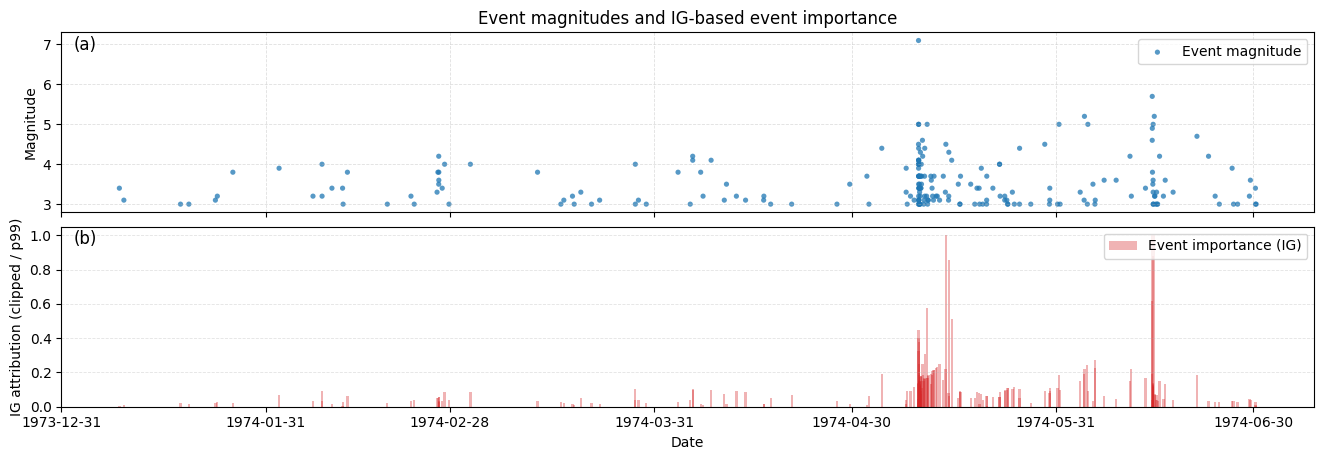

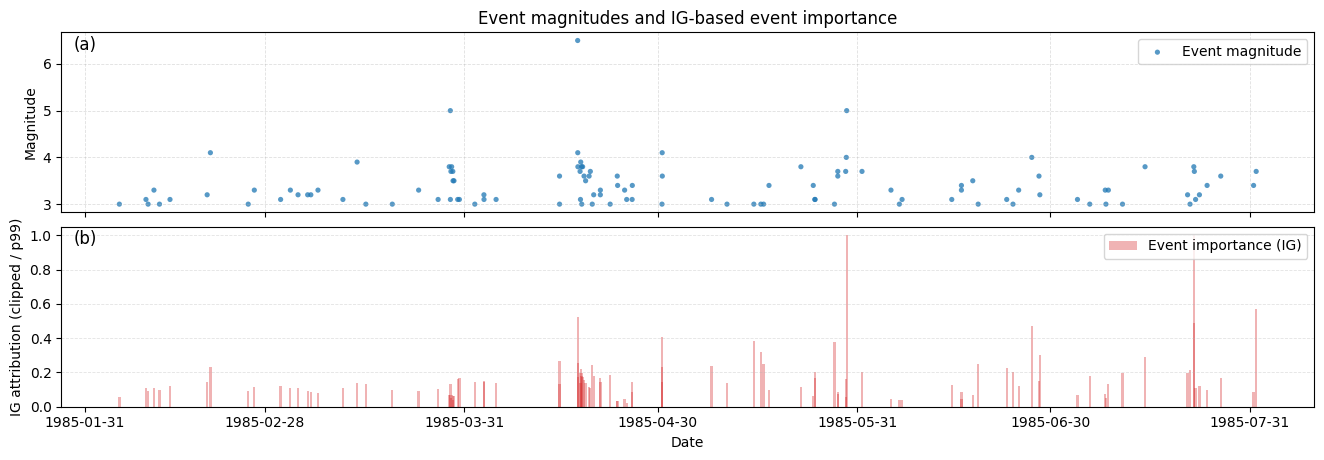

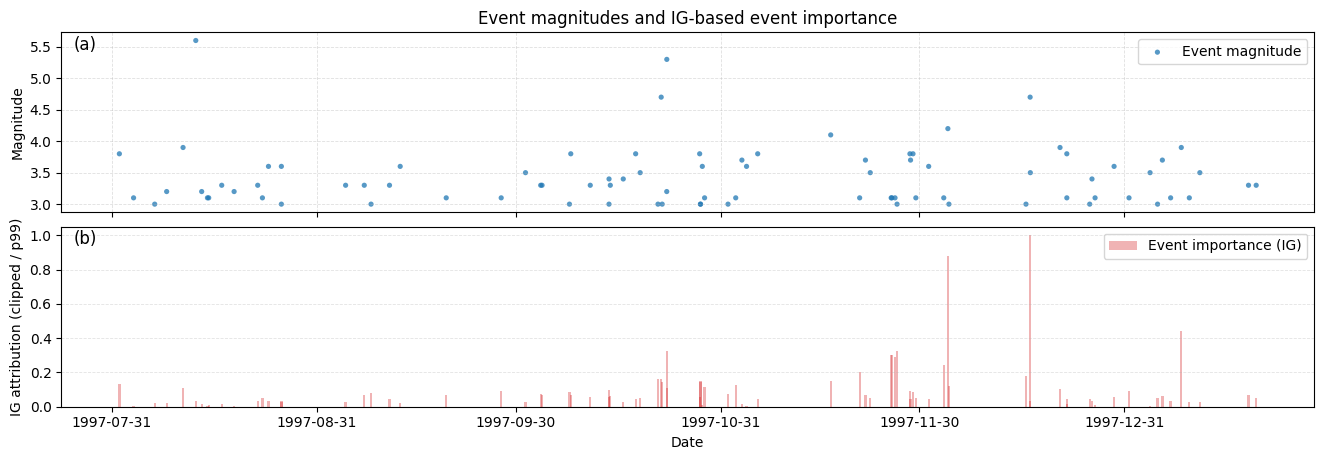

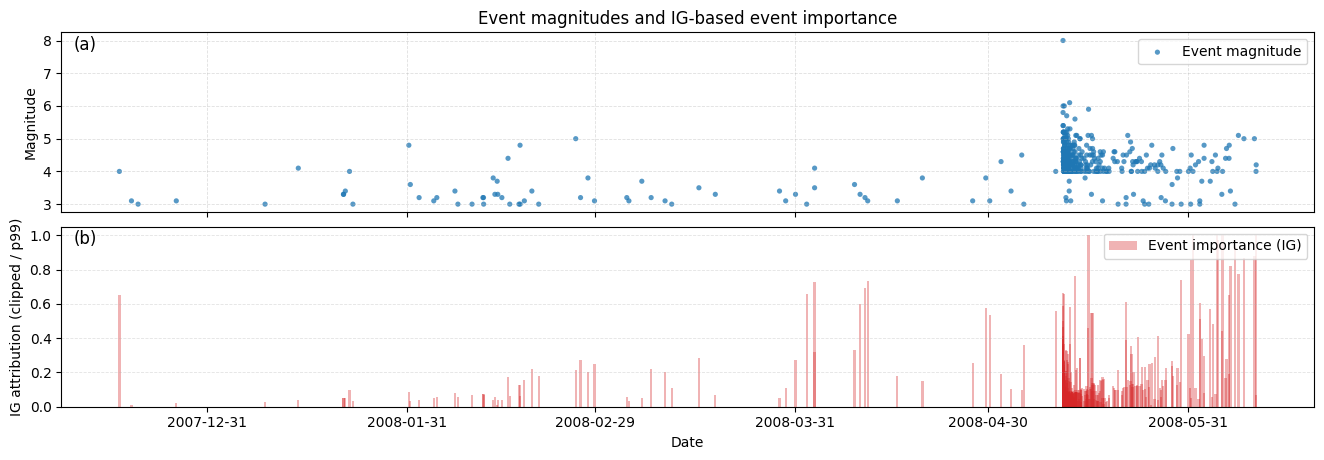

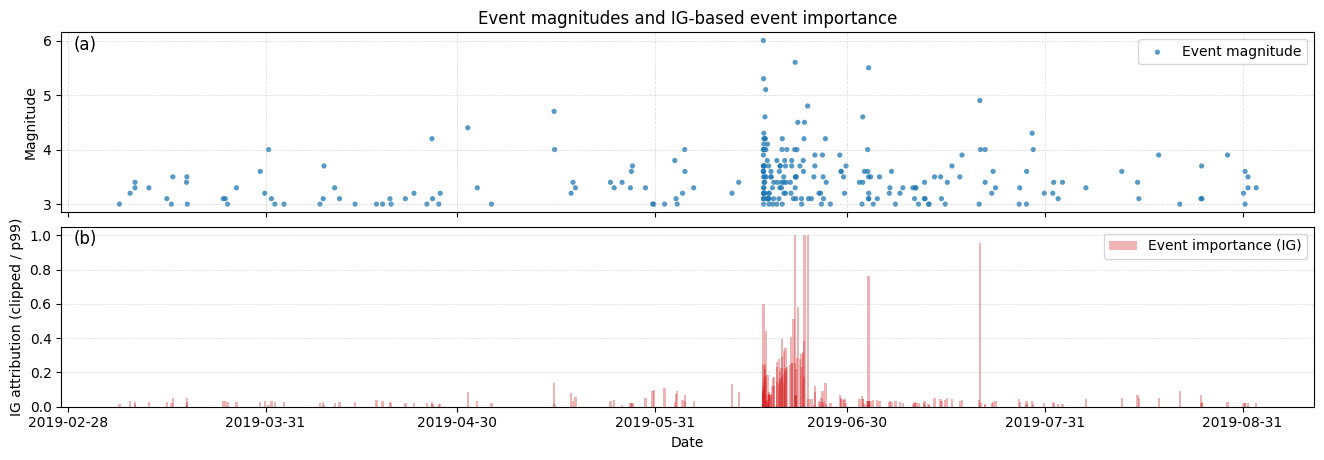

: 

In [ ]:
def batch_export_interpretability(
    model,
    data_loader,
    out_dir: Path,
    start_time,
    every_n: int = 10,
    match_mod: int = 3,
    ig_steps: int = 200,
):
    out_dir.mkdir(parents=True, exist_ok=True)

    for batch_id, (x_batch, y_batch) in enumerate(data_loader):
        if batch_id % every_n != match_mod:
            continue

        sample_idx = np.random.randint(0, x_batch.shape[0])
        scores, _ = interp.compute_token_importance(
            model,
            x_batch,
            method='ig',
            n_steps=ig_steps,
            signed=False,
        )
        mask = get_non_pad_mask(x_batch[:, :, 0]).squeeze(-1).cpu().numpy().astype(bool)

        savepath = out_dir / f'clf_interp_{batch_id}_{sample_idx}.pdf'
        interp.plot_event_magnitude_and_importance_clean(
            x_batch,
            scores,
            batch_idx=sample_idx,
            time_channel=0,
            x_axis='time',
            start_time=start_time,
            time_scale=1.0,
            time_unit='D',
            mag_channel=2,
            importance_norm='p99',
            savepath=str(savepath),
            mag_color='tab:blue',
            imp_color='tab:red',
            mask=mask,
            height_ratios=(2, 2),
            xlabel='Date',
            clip_mag=None,
            panel_labels=('(a)', '(b)'),
        )

set_seed(0)
batch_export_interpretability(
    model=model,
    data_loader=data_loader,
    out_dir=FIG_BATCH_DIR,
    start_time=t0_np,
    every_n=10,
    match_mod=3,
    ig_steps=200,
)